# Proyecto Final — Problema 2
## Fruits and Vegetables Recognizer

**Curso:** Text Mining & Image Recognition  
**Postgrado en Análisis y Predicción de Datos — Tercer Trimestre 2026**

**Integrantes**
- **20011152 — Samuel Isaac Gómez Moreno**
- **25002775 — Luis Felipe Zárate de León**

### Objetivo
Construir un clasificador de imágenes con redes neuronales convolucionales (CNN) capaz de distinguir **6 tipos de productos**:

**Frutas:** Apple, Banana, Orange  
**Vegetales:** Carrot, Potato, Tomato

Se compararán **3 arquitecturas CNN distintas** bajo el mismo conjunto de datos y se seleccionará la de mejor desempeño en el conjunto de prueba.


# Datos

Dataset oficial: **Fruits and Vegetables dataset — Mukhriddin Mukhiddinov (Kaggle)**.

El dataset original contiene cinco frutas y cinco vegetales, cada uno dividido en estado fresco y podrido. Para este ejercicio, el objetivo es reconocer el **tipo de producto**, no su frescura. Por eso se seleccionan tres frutas y tres vegetales y se agrupan las imágenes fresh/rotten del mismo producto bajo una única etiqueta.

La descarga se hace automáticamente desde Kaggle en Google Colab; **no es necesario subir manualmente los ~890 MB a GitHub**.


In [1]:
# 1. Instalación y librerías
!pip -q install kagglehub

import os, re, json, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Descargar el dataset desde Kaggle

`kagglehub` descarga el dataset directamente en Colab. La primera ejecución puede solicitar autenticación de Kaggle dependiendo de la configuración de la cuenta.


In [2]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download(
    "muhriddinmuxiddinov/fruits-and-vegetables-dataset"
))
print("Dataset descargado en:", dataset_path)


100%|██████████| 870M/870M [00:44<00:00, 20.5MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset/versions/2


## 2. Seleccionar las seis clases

Se buscan carpetas cuyo nombre contenga el producto. Las variantes **Fresh** y **Rotten** se combinan en una sola clase base.

Esto permite que, por ejemplo, tanto una manzana fresca como una manzana podrida sean clasificadas como **Apple**.


In [3]:
CLASES = ["apple", "banana", "orange", "carrot", "potato", "tomato"]
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

imagenes = []
for archivo in dataset_path.rglob("*"):
    if archivo.is_file() and archivo.suffix.lower() in IMG_EXT:
        partes = " ".join(p.lower() for p in archivo.parts)
        encontrada = next((c for c in CLASES if c in partes), None)
        if encontrada:
            imagenes.append((archivo, encontrada))

df = pd.DataFrame(imagenes, columns=["path", "class"])
print("Total seleccionado:", len(df))
display(df["class"].value_counts().sort_index())


Total seleccionado: 7200


,count
class,
apple,1200
banana,1200
carrot,1200
orange,1200
potato,1200
tomato,1200


## 3. Separación entrenamiento / validación / prueba

Se utiliza una separación estratificada aproximada:
- **70% entrenamiento**
- **15% validación**
- **15% prueba**

De esta forma las seis clases quedan representadas en los tres conjuntos.


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class"], random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 5040
Validation: 1080
Test: 1080


## 4. Preprocesamiento y Data Augmentation

Las imágenes se:
- trabajan **a color RGB**;
- redimensionan a **128 × 128**;
- normalizan de 0–255 a **0–1**;
- aumentan durante entrenamiento con **flip horizontal, rotación, zoom, traslación y contraste**.

El aumento se aplica solamente al conjunto de entrenamiento.


In [5]:
IMG_SIZE = (128, 128)
BATCH = 32

def crear_dataset(tabla, shuffle=False):
    paths = tabla["path"].astype(str).values
    labels_text = tabla["class"].values
    class_to_idx = {c:i for i,c in enumerate(CLASES)}
    labels = np.array([class_to_idx[x] for x in labels_text])

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def cargar(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(cargar, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(min(len(tabla), 5000), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = crear_dataset(train_df, shuffle=True)
val_ds = crear_dataset(val_df)
test_ds = crear_dataset(test_df)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
], name="data_augmentation")


## 5. Arquitectura CNN #1 — Básica

Modelo pequeño con dos bloques convolución + MaxPooling. Sirve como **línea base**.


In [6]:
def cnn_1():
    return keras.Sequential([
        layers.Input((*IMG_SIZE, 3)),
        data_augmentation,
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(len(CLASES), activation="softmax")
    ], name="CNN_1_Basica")


## 6. Arquitectura CNN #2 — Intermedia

Añade una tercera capa convolucional, **Dropout** y `GlobalAveragePooling2D`. Busca aprender características más complejas reduciendo el sobreajuste.


In [7]:
def cnn_2():
    return keras.Sequential([
        layers.Input((*IMG_SIZE, 3)),
        data_augmentation,
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.35),
        layers.Dense(len(CLASES), activation="softmax")
    ], name="CNN_2_Intermedia")


## 7. Arquitectura CNN #3 — Mejorada

Añade **Batch Normalization**, más filtros y Dropout. La normalización ayuda a estabilizar el entrenamiento y la regularización intenta reducir el sobreajuste.


In [8]:
def cnn_3():
    return keras.Sequential([
        layers.Input((*IMG_SIZE, 3)),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(len(CLASES), activation="softmax")
    ], name="CNN_3_Mejorada")


## 8. Entrenamiento de las tres CNN

Para que la comparación sea justa:
- las tres usan los mismos datos;
- el mismo optimizador (**Adam**);
- la misma función de pérdida;
- máximo de **15 épocas**;
- `EarlyStopping` detiene el entrenamiento si la validación deja de mejorar.


In [9]:
EPOCHS = 15

def entrenar(modelo):
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, min_lr=1e-6
        )
    ]
    history = modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    return history

modelos = [cnn_1(), cnn_2(), cnn_3()]
historias = []

for modelo in modelos:
    print("\n", "="*70)
    print("ENTRENANDO:", modelo.name)
    modelo.summary()
    historias.append(entrenar(modelo))



ENTRENANDO: CNN_1_Basica


Model: "CNN_1_Basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,902 (32.08 MB)

 Trainable params: 8,408,902 (32.08 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.5433 - loss: 1.2033 - val_accuracy: 0.1648 - val_loss: 3.0100 - learning_rate: 0.0010
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - accuracy: 0.6966 - loss: 0.8625 - val_accuracy: 0.2398 - val_loss: 2.3951 - learning_rate: 0.0010
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.7571 - loss: 0.7044 - val_accuracy: 0.5491 - val_loss: 1.2141 - learning_rate: 0.0010
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.7837 - loss: 0.6346 - val_accuracy: 0.7806 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8016 - loss: 0.5778 - val_accuracy: 0.7231 - val_loss: 0.8589 - learning_rate: 0.0010
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.8169 - loss: 0.5441 - val_accuracy: 0.7167 - val_loss: 0.8207 - learning_rate: 0.0010
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.8536 - l

## 9. Curvas de aprendizaje

Estas gráficas permiten observar si el modelo está aprendiendo y detectar posible sobreajuste.


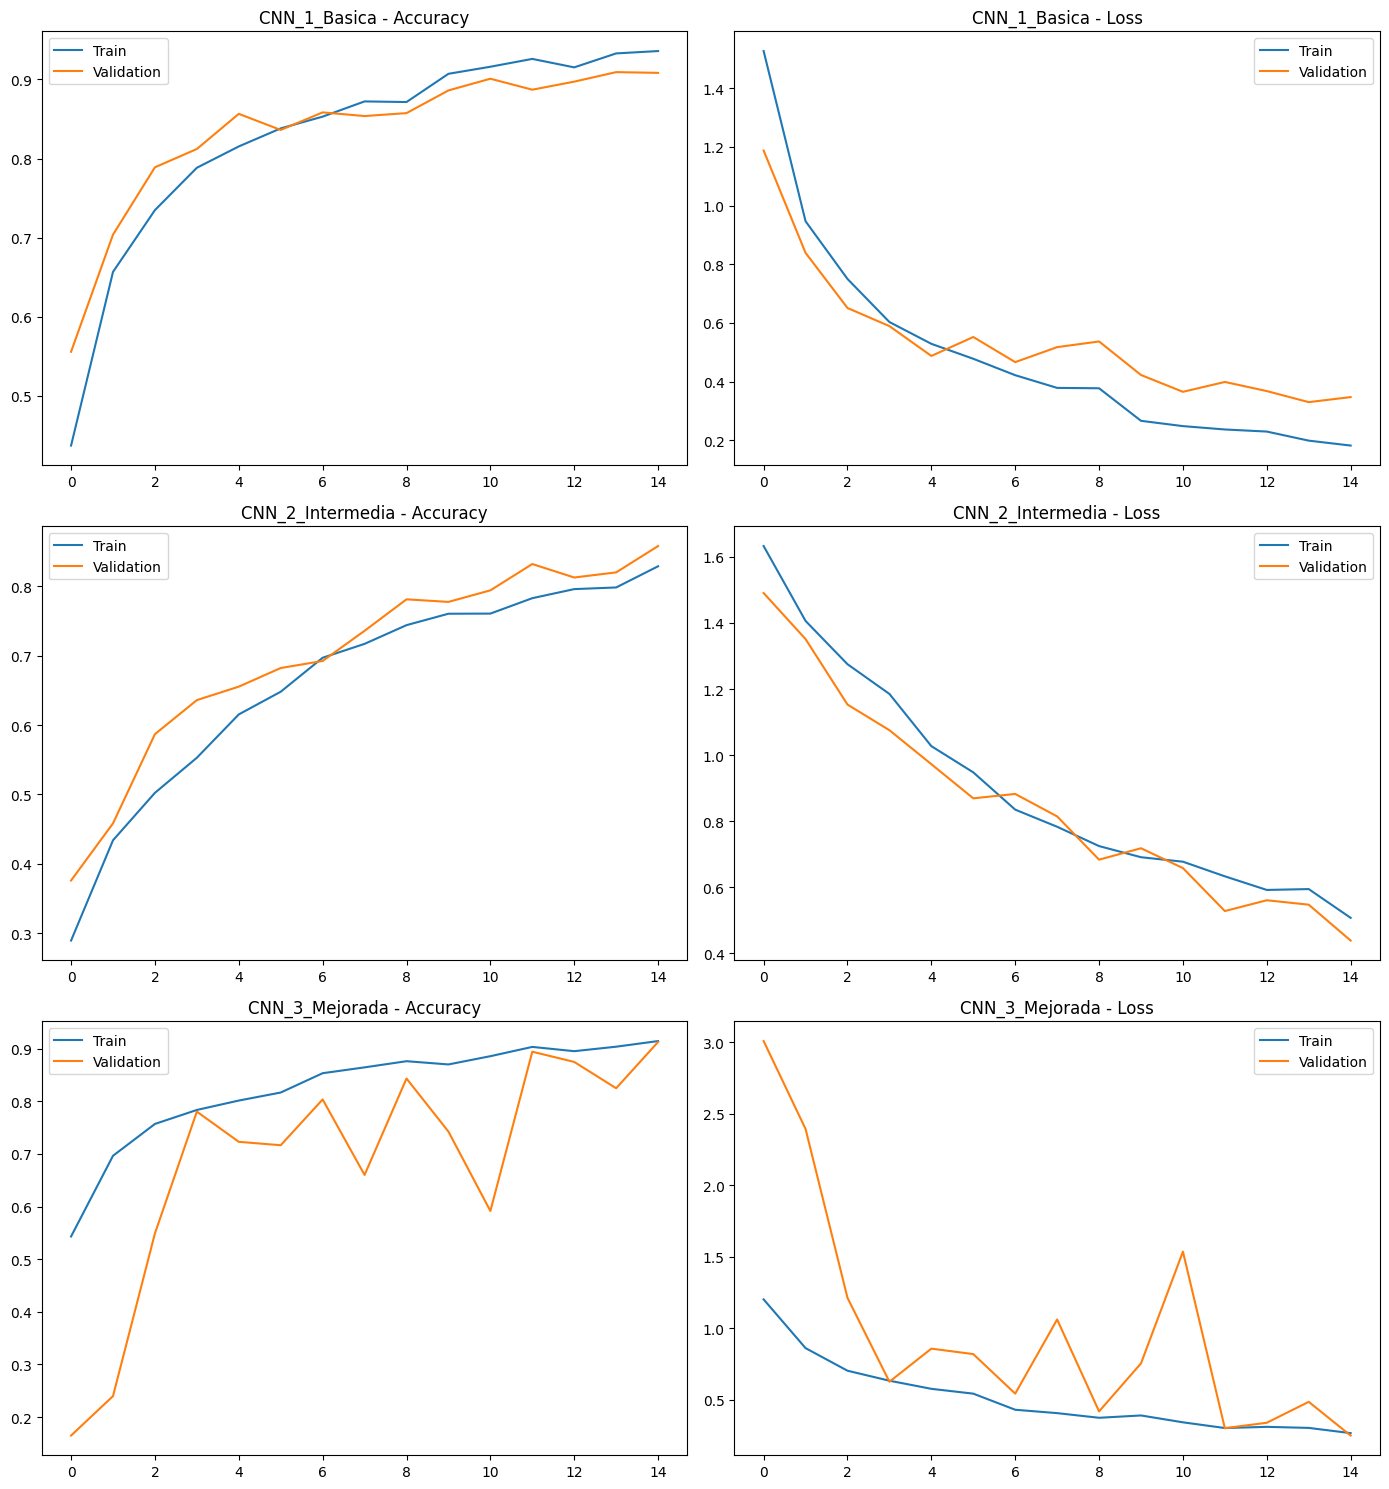

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for i, (modelo, hist) in enumerate(zip(modelos, historias)):
    axes[i,0].plot(hist.history["accuracy"], label="Train")
    axes[i,0].plot(hist.history["val_accuracy"], label="Validation")
    axes[i,0].set_title(f"{modelo.name} - Accuracy")
    axes[i,0].legend()

    axes[i,1].plot(hist.history["loss"], label="Train")
    axes[i,1].plot(hist.history["val_loss"], label="Validation")
    axes[i,1].set_title(f"{modelo.name} - Loss")
    axes[i,1].legend()

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=160)
plt.show()


## 10. Evaluación en prueba y comparación final

**Importante:** la selección del mejor modelo se realiza con los resultados que realmente produzca la ejecución. No se inventan métricas.


In [11]:
resultados = []

for modelo in modelos:
    loss, acc = modelo.evaluate(test_ds, verbose=0)
    resultados.append({
        "Modelo": modelo.name,
        "Test Loss": loss,
        "Test Accuracy": acc
    })

comparacion = pd.DataFrame(resultados).sort_values(
    "Test Accuracy", ascending=False
).reset_index(drop=True)

display(comparacion)
comparacion.to_csv("comparacion_modelos.csv", index=False)

mejor_nombre = comparacion.loc[0, "Modelo"]
mejor_modelo = next(m for m in modelos if m.name == mejor_nombre)

print("Mejor modelo según Test Accuracy:", mejor_nombre)


,Modelo,Test Loss,Test Accuracy
0,CNN_1_Basica,0.344062,0.909259
1,CNN_3_Mejorada,0.276100,0.907407
2,CNN_2_Intermedia,0.477419,0.846296


Mejor modelo según Test Accuracy: CNN_1_Basica


## 11. Matriz de confusión y métricas del mejor modelo

Aquí revisamos no solo cuántas imágenes acierta, sino **en qué clases se confunde**.


              precision    recall  f1-score   support

       apple     0.9040    0.8889    0.8964       180
      banana     0.9101    0.9000    0.9050       180
      orange     0.9543    0.9278    0.9408       180
      carrot     0.8653    0.9278    0.8954       180
      potato     0.9086    0.8833    0.8958       180
      tomato     0.9176    0.9278    0.9227       180

    accuracy                         0.9093      1080
   macro avg     0.9100    0.9093    0.9094      1080
weighted avg     0.9100    0.9093    0.9094      1080



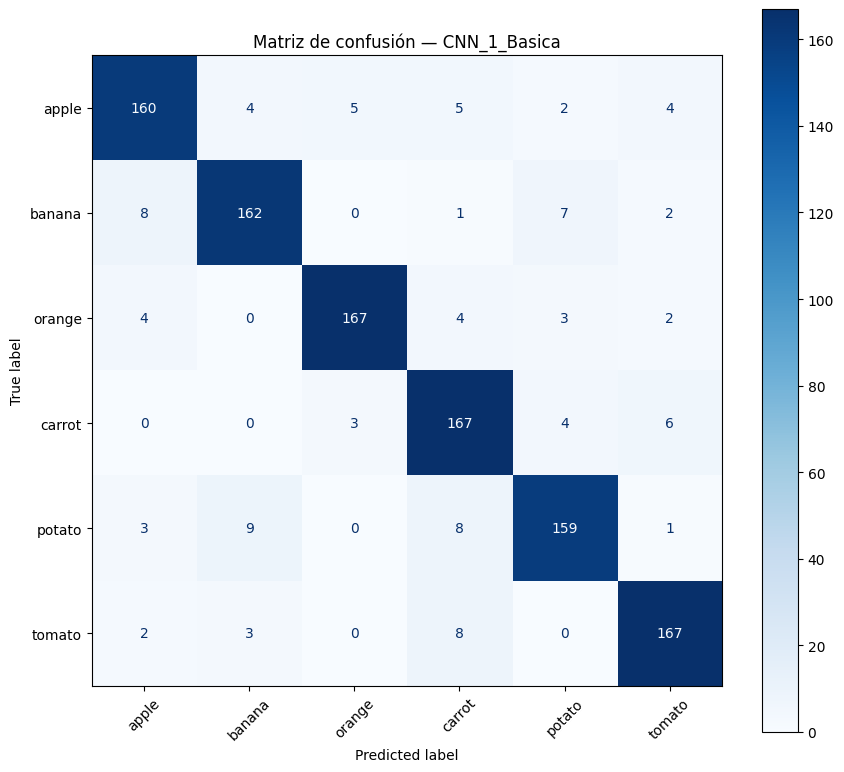

In [12]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
prob = mejor_modelo.predict(test_ds, verbose=0)
y_pred = np.argmax(prob, axis=1)

print(classification_report(
    y_true, y_pred,
    target_names=CLASES,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASES)
fig, ax = plt.subplots(figsize=(9,8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Matriz de confusión — {mejor_nombre}")
plt.tight_layout()
plt.savefig("matriz_confusion_mejor_modelo.png", dpi=160)
plt.show()


## 12. Guardar el mejor modelo


In [13]:
mejor_modelo.save("mejor_modelo_frutas_vegetales.keras")
print("Modelo guardado.")


Modelo guardado.


## Conclusión final

Se evaluaron **tres arquitecturas de redes neuronales convolucionales (CNN)** utilizando el mismo conjunto de datos de **7,200 imágenes**, correspondientes a seis categorías: **apple, banana, orange, carrot, potato y tomato**.

Los resultados obtenidos en el conjunto de prueba fueron:

| Modelo | Test Loss | Test Accuracy |
|---|---:|---:|
| **CNN_1_Basica** | 0.344062 | **90.93%** |
| CNN_3_Mejorada | **0.276100** | 90.74% |
| CNN_2_Intermedia | 0.477419 | 84.63% |

Siguiendo el criterio definido en el proyecto de seleccionar la arquitectura con mayor **Test Accuracy**, la arquitectura seleccionada es **CNN_1_Basica**, con una exactitud de **90.93%**.

En las **1,080 imágenes de prueba**, CNN_1_Basica clasificó correctamente **982 imágenes** y cometió **98 errores**. La matriz de confusión muestra un comportamiento bastante equilibrado entre las seis categorías. **Orange, carrot y tomato** alcanzaron un *recall* de **92.78%**, mientras que **potato** presentó el menor *recall*, con **88.33%**.

También es importante observar que **CNN_3_Mejorada** obtuvo un resultado muy cercano en exactitud (**90.74%**) y consiguió el menor **Test Loss (0.2761)**. Esto demuestra que una arquitectura más profunda o compleja no necesariamente obtiene la mayor exactitud de clasificación.

### Interpretación sencilla

Podemos imaginar que las tres CNN son tres estudiantes que hicieron el mismo examen. **CNN_1_Basica respondió correctamente un poco más de preguntas**, por eso obtuvo la mayor exactitud. CNN_3 estuvo muy cerca y tuvo una pérdida menor, mientras que CNN_2 obtuvo un desempeño inferior. Por esa razón, para este proyecto se selecciona **CNN_1_Basica** como el modelo final según el criterio de mayor *Test Accuracy*.


# Explicación sencilla

Imaginemos que enseñamos a tres niños a reconocer frutas y verduras.

- **CNN 1** mira pocas características.
- **CNN 2** observa más detalles y además aprende a no depender demasiado de una sola pista.
- **CNN 3** tiene más etapas para buscar bordes, colores, formas y texturas.

Durante el entrenamiento les mostramos muchos ejemplos. El **Data Augmentation** es como mostrar la misma manzana girada, acercada o con pequeñas variaciones para que aprendan que sigue siendo una manzana.

Después hacemos un examen con imágenes que nunca habían visto. El modelo que mejor responde en ese examen es el que seleccionamos.
